In [4]:
import numpy as np
from numpy.typing import NDArray

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent / "src"))

from hopfield.network import run_network
from hopfield import corrupt

from hopfield.network import rng

In [5]:
# template pour cmap noir et blanc
cmap_nb = mcolors.LinearSegmentedColormap.from_list("noir_blanc", ["black", "white"])
norm = mcolors.Normalize(vmin=-1, vmax=1)

weight_hebb took 3.245513 s
update_asynch took 2.590380 s
weight_hebb took 2.972940 s
update_asynch took 2.609708 s
weight_hebb took 2.954019 s
update_asynch took 2.514322 s


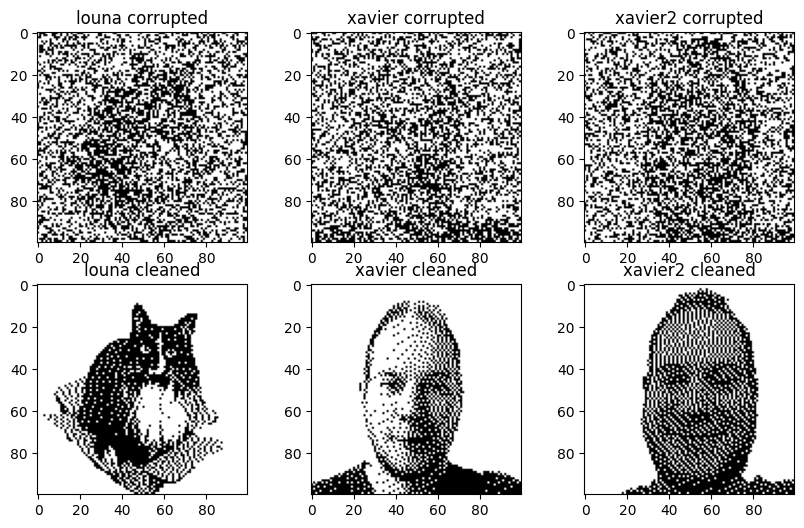

In [11]:
louna = np.array(np.loadtxt("../src/hopfield/data/image1_100x100_matrix.txt"),
                    dtype= np.int8)
xavier = np.array(np.loadtxt("../src/hopfield/data/image2_100x100_matrix.txt"), 
                    dtype=np.int8)
xavier2 = np.array(np.loadtxt("../src/hopfield/data/image3_100x100_matrix.txt"), 
                    dtype=np.int8)

patterns_xl = np.array([  louna.reshape(10_000,),
                            xavier.reshape(10_000,), 
                        xavier2.reshape(10_000,)])

louna_corr   = corrupt.corrupt_pattern(  louna.reshape(10_000,), 0.35, rng)
xavier_corr  = corrupt.corrupt_pattern( xavier.reshape(10_000,), 0.35, rng)
xavier2_corr = corrupt.corrupt_pattern(xavier2.reshape(10_000,), 0.35, rng)

louna_clean   = run_network(patterns_xl, louna_corr,   rng)
xavier_clean  = run_network(patterns_xl, xavier_corr,  rng)
xavier2_clean = run_network(patterns_xl, xavier2_corr, rng)

plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(louna_corr.reshape(100,100), cmap=cmap_nb, norm=norm)
plt.title("louna corrupted")

plt.subplot(2,3,4)
plt.imshow(louna_clean.reshape(100,100), cmap=cmap_nb, norm=norm)
plt.title("louna cleaned")

plt.subplot(2,3,2)
plt.imshow(xavier_corr.reshape(100,100), cmap=cmap_nb, norm=norm)
plt.title("xavier corrupted")

plt.subplot(2,3,5)
plt.imshow(xavier_clean.reshape(100,100), cmap=cmap_nb, norm=norm)
plt.title("xavier cleaned")

plt.subplot(2,3,3)
plt.imshow(xavier2_corr.reshape(100,100), cmap=cmap_nb, norm=norm)
plt.title("xavier2 corrupted")

plt.subplot(2,3,6)
plt.imshow(xavier2_clean.reshape(100,100), cmap=cmap_nb, norm=norm)
plt.title("xavier2 cleaned")


plt.show()